# **Read input files**
================================================================================

Exclude **SMOKE** given that both are two different concepts


The iconicity value was taken from the file iconicity_ASL.csv
The version number is with respesct to the model version to generate MHI, both with ~4K dimensions. signERT has 192 dimensions.

Type of Phonological Embedding

*   MHI-Only: gets the emedding from the Movement Historic Image
    1.   ASL: emb_phono_ASL_MHIv3.csv
    2.   LSP: emb_phono_LSP_MHIv3.csv
*   signERT: gets the embedding from the very previous to the last layer form the model signERT
    1.   ASL: emb_phono_ASL_signERT.csv
    2.   LSP: emb_phono_LSP_signERT.csv
*   MHI-signERT:  gets the embedding by combining MHI and the keypoints
    1.   ASL: emb_phono_ASL_MHIsignERT.csv
    2.   LSP: emb_phono_ASL_MHIsignERT.csv

Type of Semantic Embedding

*   ASL: emb_semantic_ASL_fastText.csv
*   LSP: emb_semantic_LSP_fastText.csv



Type of Reduction

*   PCA
*   TSNE
*   PCA_TSNE




## Análisis Densidad

In [1]:
"""
Análisis Densidad y la prediccion de la Iconicidad en base a la densidad fonologica ASL Y LSP
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
import statsmodels.api as sm
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("🎵 ANÁLISIS DE DENSIDAD: ASL vs LSP")

# ==============================================================================
# ETAPA 1: CARGAR DATOS LIMPIOS AND SETTING GENERAL VALUES
# ==============================================================================

print("\n" + "="*80)
print("📦 ETAPA 1: CARGANDO DATOS LIMPIOS")
print("="*80)

asl_data = pd.read_csv("emb_phono_median_ASL_MHIv5.csv") #MHIv3 #signERTv1 #MHIv3signERTv1 #FASTTEXT
lsp_data = pd.read_csv("emb_phono_median_LSP_MHIv5.csv")

# CHOOSE EMBEDDING TYPE: SEMANTIC or PHONOLOGICAL
analysisType = "PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new"
modelType = "MHIv5"
numberOfSignsForDensity = 3/4 ### Not used yet but for frequency



🎵 ANÁLISIS DE DENSIDAD: ASL vs LSP

📦 ETAPA 1: CARGANDO DATOS LIMPIOS


In [2]:
# Creating folder to save results images and CSV.
import os
from pathlib import Path

folder_path = Path(analysisType)

if folder_path.is_dir():
    print(f"The folder '{folder_path}' exists.")
else:
  os.mkdir(analysisType)

In [3]:
asl_data.columns

Index(['word', 'iconicity', '0', '1', '2', '3', '4', '5', '6', '7',
       ...
       '4054', '4055', '4056', '4057', '4058', '4059', '4060', '4061', '4062',
       '4063'],
      dtype='object', length=4066)

In [4]:
lsp_data.columns

Index(['word', 'EnglishGloss', 'iconicity', '0', '1', '2', '3', '4', '5', '6',
       ...
       '4054', '4055', '4056', '4057', '4058', '4059', '4060', '4061', '4062',
       '4063'],
      dtype='object', length=4067)

In [5]:
# Identificar columnas
embedding_cols = [col for col in asl_data.columns if col not in ['asl_gloss','lsp_gloss','word', 'EnglishGloss', 'SpanishGloss', 'iconicity','frequency','iconicity_std', 'global_centrality', 'neighbor_k5',
       'neighbor_k10', 'neighbor_k20', 'neighbor_k30', 'neighbor_k50', 'local_concentration']]
n_dims = len(embedding_cols)

print(f"\n✅ Datos cargados:")
print(f"   • ASL: {len(asl_data)} señas × {n_dims} dimensiones")
print(f"   • LSP: {len(lsp_data)} señas × {n_dims} dimensiones")
print(f"   • Columnas: word, iconicity + {n_dims} dims")





✅ Datos cargados:
   • ASL: 105 señas × 4064 dimensiones
   • LSP: 105 señas × 4064 dimensiones
   • Columnas: word, iconicity + 4064 dims


In [6]:
# Estandarizar iconicidad
def fnstandardize(data, name):
  print("\n🔹 Estandarizando iconicidad...")
  data['iconicity_standard'] = (data['iconicity'] - data['iconicity'].mean()) / data['iconicity'].std()
  print(f"\n✅ Iconicidad estandarizada:")
  print(f"   {name} - Media: {data['iconicity_standard'].mean():.3f}, Std: {data['iconicity_standard'].std():.3f}")
  return data

standardize = False
if standardize:
  asl_data = fnstandardize(asl_data, "ASL")
  lsp_data = fnstandardize(lsp_data, "LSP")

In [7]:
asl_data.head(3)

,word,iconicity,0,1,2,3,4,5,6,7,...,4054,4055,4056,4057,4058,4059,4060,4061,4062,4063
0,BIRD-CLAW,3.000000,0.001705,0.002673,0.005064,-0.005220,-0.004026,-0.002205,0.002159,0.030088,...,-0.012414,0.022078,-0.012414,0.002878,-0.012414,-0.012414,-0.012414,0.008552,-0.012414,0.004493
1,RECTANGULAR-PAPER,3.512821,0.002653,0.001493,0.005999,-0.005154,-0.002817,-0.004028,0.000244,0.030819,...,-0.011303,0.009816,-0.012419,0.032016,-0.012419,-0.012419,-0.012419,0.014523,-0.012419,0.016621
2,JUMP,4.128205,0.003460,0.001537,0.007059,-0.004941,-0.003610,-0.003002,-0.000304,0.029036,...,-0.012565,0.006065,-0.012565,0.026224,-0.012565,-0.012565,-0.012565,0.008434,-0.012565,-0.009662


In [8]:
#print(asl_data.head)
#print(lsp_data.head)

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
import statsmodels.api as sm

In [10]:
len(embedding_cols)

4064

In [11]:
# ==============================================================================
# ETAPA 4: DENSIDAD FONOLÓGICA
# ==============================================================================

print("\n" + "="*80)
print("📏 ETAPA 4: DENSIDAD FONOLÓGICA")
print("="*80)

def calculate_phonological_density(data, embedding_cols):
    """Calcular métricas de densidad fonológica"""

    print("\n🔹 Calculando métricas de densidad...")

    # Extrae solo las columnas de embeddings fonológicos (4,064 dimensiones)

    X = data[embedding_cols].values #X = matriz de (102 señas × 4,064 dims)
    n_samples = X.shape[0]
    print(f"   • {n_samples} señas × {X.shape[1]} dims")

    print("   • Calculando similitud de coseno...")
    #Calcula la similitud de coseno** entre TODAS las señas
    #Resultado: matriz de 102×102
    #`sim_matrix[i][j]` = qué tan similar es la seña i con la seña j
    sim_matrix = cosine_similarity(X)

    #print(sim_matrix)

    # 1. Centralidad Global
    print("   • Centralidad global...")
    # por qué menos
    #`sim_matrix.sum(axis=1)` → suma todas las similitudes de cada seña con las demás (suma las columnas )
    #`- 1` → resta la similitud consigo misma (que siempre es 1.0)
    global_centrality = sim_matrix.sum(axis=1) - 1
    #print(global_centrality)

    #Adicionar una query para cuando tenemos las mas frecuentes

    # 2. Concentración de Vecinos (suma de similitudes con los K vecinos MÁS CERCANOS)
    print("   • Concentración de vecinos...")
    neighbor_conc = {}
    # por qué se hace para 5, 10, 20 ...
    # Thompson hizo laspruebas con 5, 10, 20 ,50 y 100
    for k in [5, 10, 20, 30,50]:
        if k < n_samples:
            # Usa sim_matrix la matriz de 102×102 del cosine similarity
            #np.partition: Ordena parcialmente un array para que los k elementos más grandes queden al final.
            #k = 2
            # ```
            # Índices:  0     1     2     3     4
            #         [1.00, 0.85, 0.12, 0.45, 0.23]
            #          ↑     ↑     ↑     ↑     ↑
            #         -5    -4    -3    -2    -1
            # ```

            # **Después de `np.partition(array, -3)`:**
            # ```
            #         [0.12, 0.23, 0.45, 0.85, 1.00]
            #          ↑     ↑     ↑     ↑     ↑
            #         -5    -4    -3    -2    -1
            #                     └───────────┘
            #                     Los 3 más grandes
             #[:, -k-1:] -> todas las filas, toma todas las columnas desde -k-1 hasta el final
            #[:, -3:]  → todas las filas, toma todas las columnas desde -3 hasta el final (serian 3 columnas)
            # -k-1 porque queremeos los k vecinos mas self : Tenemos k=2 vecinos + self
            top_k_sims = np.partition(sim_matrix, -k-1, axis=1)[:, -k-1:]
            #top_k_sims = es una matriz con las k+1 similitudes más altas para cada seña.
            #top_k_sims.sum(axis=1) toma cada fila y suma las columnas
            # #`- 1` → resta la similitud consigo misma (que siempre es 1.0)
            neighbor_conc[f'neighbor_k{k}'] = top_k_sims.sum(axis=1) -1
            #print(neighbor_conc[f'neighbor_k{k}'])

    # 3. Concentración Local
    print("   • Concentración local...")
    # Thompson 191: Local concentration is the sum of a word's cosine similarity to all other words which exceed a similarity threshold (defined somewhat arbitrarily as the mean of the overall distribution of cosine similarities... plus one standard deviation
    ## sim_matrix.mean(): Media de todos los valores
    # sim_matrix.std() : # Desviación estándar
    #Threshold = umbral de similitud "alta" given the cosine similarity goes from -1 to 1
    threshold = sim_matrix.mean() + sim_matrix.std()
    print("Threshold: ", threshold)
    ### **Aplicar comparación `> 0.813`:**
    # ```
    #            DRINK   EAT   BABY   SCISS  TELEP
    # DRINK      True   True   False  False  False
    #            ↑      ↑
    #           1.00   0.85
    #         > 0.813 > 0.813
    #     Interpretación: True = similitud suficientemente alta (> 0.813) | False = similitud baja (≤ 0.813)
    # [1,    1,    0,    0,    0   ]  ← máscara
    #│           DRINK   EAT   BABY   SCISS  TELEP               │
    #│ DRINK     1.00   0.85   0.00   0.00   0.00
    #.sum(axis=1) : toma cada fila y va sumando las columnas
    # -1 : se resta asi mismo como en los otros casos
    local_conc = (sim_matrix * (sim_matrix > threshold)).sum(axis=1) - 1

    # Agregar al dataframe
    print("Global Centrality")
    data['global_centrality'] = global_centrality
    #print(data[['word', 'iconicity', 'global_centrality']].head(10))

    for key, values in neighbor_conc.items():
        print(f"{key}")
        # print(values)
        data[key] = values
    data['local_concentration'] = local_conc

    print(f"\n✅ dataframe:")

    #print(data[['word', 'iconicity', 'global_centrality', 'neighbor_k5', 'neighbor_k10', 'neighbor_k20', 'neighbor_k50','local_concentration' ]].head(10))

    print(f"\n✅ Métricas calculadas:")
    print(f"   • Centralidad global [min, max]: [{global_centrality.min():.2f}, {global_centrality.max():.2f}]")
    for key, values in neighbor_conc.items():
        print(f"   • {key} [min,max]: [{values.min():.2f}, {values.max():.2f}]")
    print(f"   • Concentración local [min,max]]: [{local_conc.min():.2f}, {local_conc.max():.2f}]")

    return data

asl_data = calculate_phonological_density(asl_data, embedding_cols)
lsp_data = calculate_phonological_density(lsp_data, embedding_cols)

print("\n" + "="*80)
print("✅ ETAPA 4 COMPLETADA")
print("="*80)


📏 ETAPA 4: DENSIDAD FONOLÓGICA

🔹 Calculando métricas de densidad...
   • 105 señas × 4064 dims
   • Calculando similitud de coseno...
   • Centralidad global...
   • Concentración de vecinos...
   • Concentración local...
Threshold:  0.8117111006149874
Global Centrality
neighbor_k5
neighbor_k10
neighbor_k20
neighbor_k30
neighbor_k50

✅ dataframe:

✅ Métricas calculadas:
   • Centralidad global [min, max]: [71.01, 83.29]
   • neighbor_k5 [min,max]: [3.72, 4.44]
   • neighbor_k10 [min,max]: [7.39, 8.76]
   • neighbor_k20 [min,max]: [14.58, 17.26]
   • neighbor_k30 [min,max]: [21.65, 25.71]
   • neighbor_k50 [min,max]: [35.48, 42.16]
   • Concentración local [min,max]]: [-0.00, 42.69]

🔹 Calculando métricas de densidad...
   • 105 señas × 4064 dims
   • Calculando similitud de coseno...
   • Centralidad global...
   • Concentración de vecinos...
   • Concentración local...
Threshold:  0.6678832433604249
Global Centrality
neighbor_k5
neighbor_k10
neighbor_k20
neighbor_k30
neighbor_k50

✅

# We'd like to analyze the distribution of globa centraliy and the other density metrics

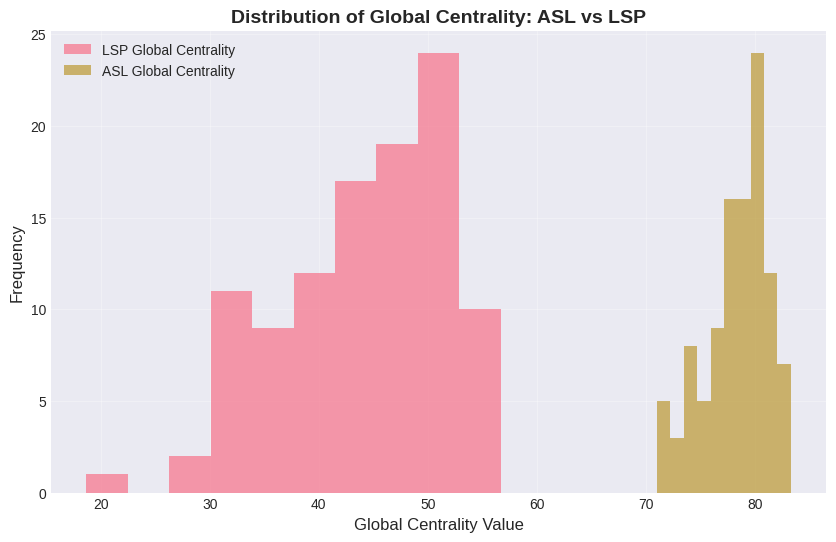

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(lsp_data["global_centrality"], alpha=0.7, label='LSP Global Centrality', bins=10)
plt.hist(asl_data["global_centrality"], alpha=0.7, label='ASL Global Centrality', bins=10)
plt.title('Distribution of Global Centrality: ASL vs LSP', fontsize=14, fontweight='bold')
plt.xlabel('Global Centrality Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f'{analysisType}/global_centrality_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

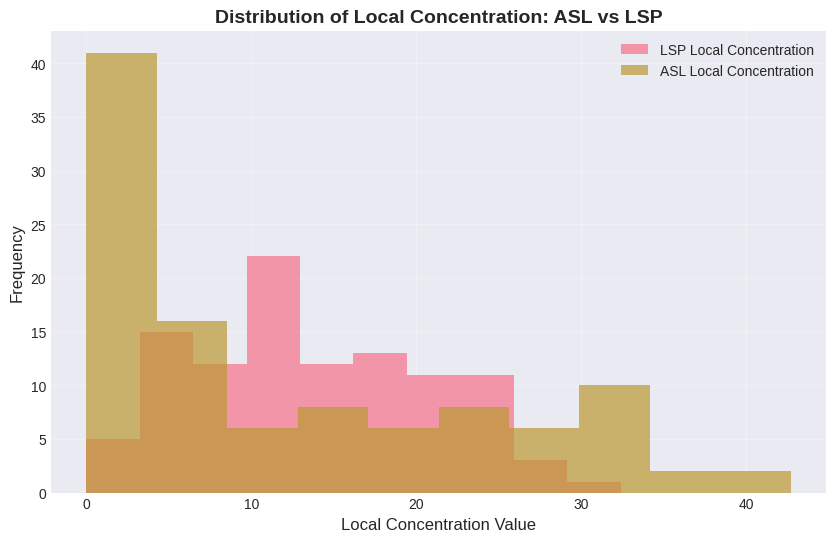

In [13]:
#  threshold 0 - 0-30 and 0-40

plt.figure(figsize=(10, 6))
plt.hist(lsp_data["local_concentration"], alpha=0.7, label='LSP Local Concentration', bins=10)
plt.hist(asl_data["local_concentration"], alpha=0.7, label='ASL Local Concentration', bins=10)
plt.title('Distribution of Local Concentration: ASL vs LSP', fontsize=14, fontweight='bold')
plt.xlabel('Local Concentration Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f'{analysisType}/local_concentrationd_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

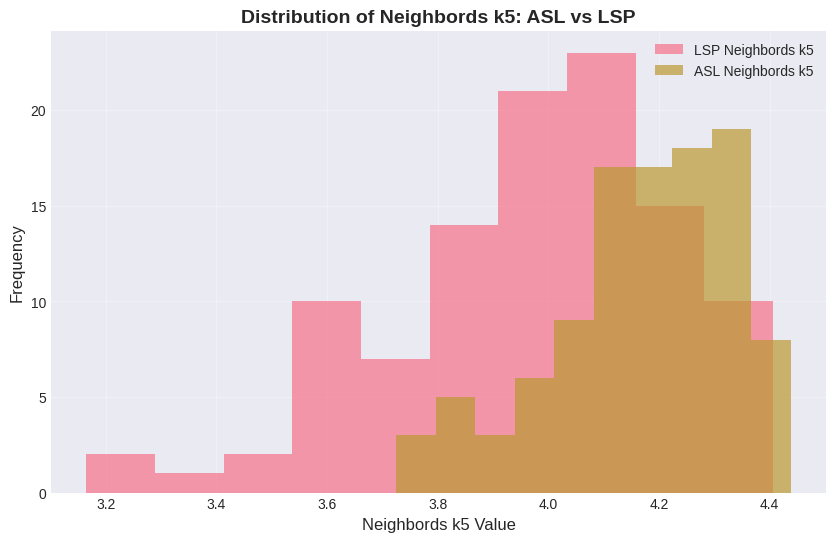

In [14]:
#plt.hist(lsp_data["neighbor_k5"])
#plt.hist(asl_data["neighbor_k5"])

plt.figure(figsize=(10, 6))
plt.hist(lsp_data["neighbor_k5"], alpha=0.7, label='LSP Neighbords k5', bins=10)
plt.hist(asl_data["neighbor_k5"], alpha=0.7, label='ASL Neighbords k5', bins=10)
plt.title('Distribution of Neighbords k5: ASL vs LSP', fontsize=14, fontweight='bold')
plt.xlabel('Neighbords k5 Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f'{analysisType}/neighborsK5_concentrationd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

PHONOLOGICAL: Viendo los histogramas de global_centrality, vemos que las señas en LSP tienen menores similaridad (mayor distancia) o están más lejos globalmente hablando comparadas con ASL.

SEMANTIC: Ocurre lo mismo. LSP 0-25 y ASL 5-45

In [15]:
print("Checking for NaN values in ASL data relevant for analysis:")

# Columns used for density metrics
density_cols = ['global_centrality', 'neighbor_k5', 'local_concentration']

# Iconicity column
iconicity_col = 'iconicity' # Assuming 'iconicity' is the column used, based on the previous cell's execution for `standardize = False`

# Check for NaNs in density columns
for col in density_cols:
    if col in asl_data.columns:
        nan_count = asl_data[col].isnull().sum()
        if nan_count > 0:
            print(f"  Column '{col}' has {nan_count} NaN values.")
        else:
            print(f"  Column '{col}' has no NaN values.")
    else:
        print(f"  Warning: Column '{col}' not found in asl_data.")

# Check for NaNs in iconicity column
if iconicity_col in asl_data.columns:
    nan_count_iconicity = asl_data[iconicity_col].isnull().sum()
    if nan_count_iconicity > 0:
        print(f"  Column '{iconicity_col}' has {nan_count_iconicity} NaN values.")
    else:
        print(f"  Column '{iconicity_col}' has no NaN values.")
else:
    print(f"  Warning: Column '{iconicity_col}' not found in asl_data.")

print("\nOverall NaN check for critical columns in ASL data complete.")

Checking for NaN values in ASL data relevant for analysis:
  Column 'global_centrality' has no NaN values.
  Column 'neighbor_k5' has no NaN values.
  Column 'local_concentration' has no NaN values.
  Column 'iconicity' has no NaN values.

Overall NaN check for critical columns in ASL data complete.


In [16]:
nan_iconicity_words = asl_data[asl_data['iconicity'].isnull()]['word']
if not nan_iconicity_words.empty:
    print("Word(s) with NaN iconicity value:")
    for word in nan_iconicity_words:
        print(f"- {word}")
else:
    print("No words found with NaN iconicity value.")

No words found with NaN iconicity value.


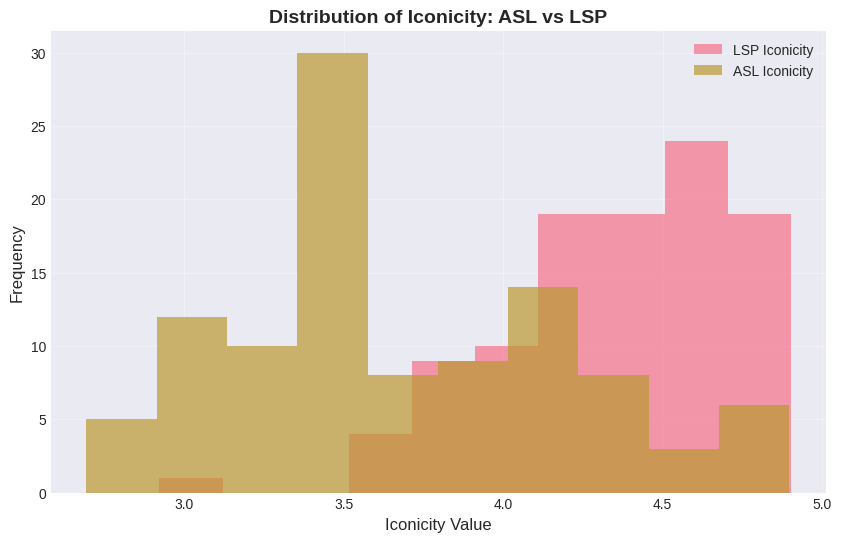

In [17]:
#plt.hist(asl_data["iconicity"])
#plt.hist(lsp_data["iconicity"])

plt.figure(figsize=(10, 6))
plt.hist(lsp_data["iconicity"], alpha=0.7, label='LSP Iconicity', bins=10)
plt.hist(asl_data["iconicity"], alpha=0.7, label='ASL Iconicity', bins=10)
plt.title('Distribution of Iconicity: ASL vs LSP', fontsize=14, fontweight='bold')
plt.xlabel('Iconicity Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(f'{analysisType}/iconicity_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

In [18]:
#plt.hist(asl_data["iconicity_standard"])

In [19]:
def getTopFreq():
  # Sort the signs by the frequency and

  return data


📊 ETAPA 5: ANÁLISIS DENSIDAD → ICONICIDAD

Hipótesis Thompson: Densidad ALTA → Iconicidad BAJA (β < 0)

📊 ASL

🔹 Métrica: global_centrality
   • β = -0.0347 (📉 NEGATIVO)
   • p-value = 0.0499 (✅ SIGNIFICATIVO)
   • R² = 0.0368
   💡 CONFIRMA HIPÓTESIS: Mayor densidad → Menor iconicidad


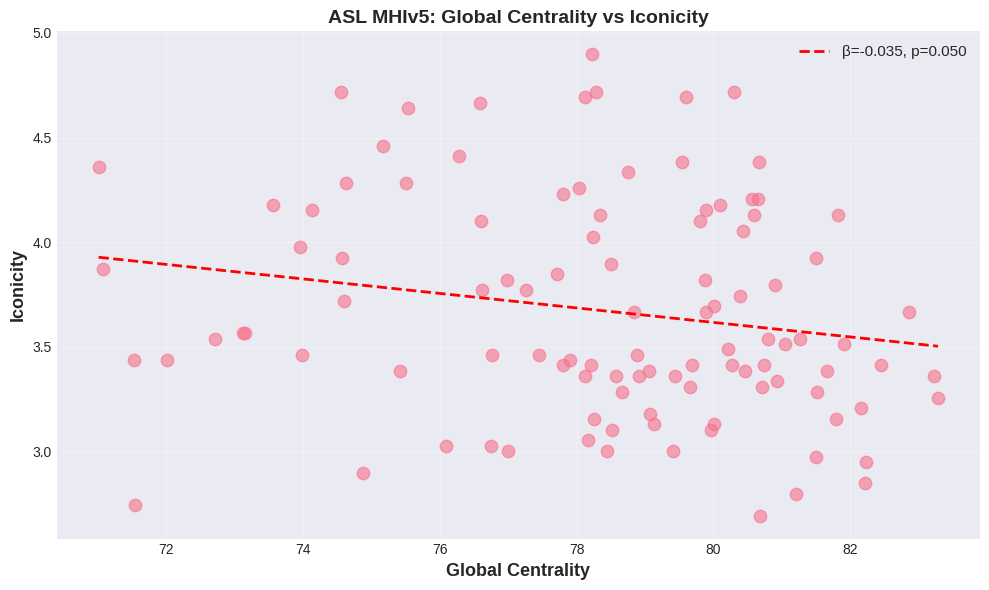


🔹 Métrica: neighbor_k5
   • β = -0.7284 (📉 NEGATIVO)
   • p-value = 0.0191 (✅ SIGNIFICATIVO)
   • R² = 0.0522
   💡 CONFIRMA HIPÓTESIS: Mayor densidad → Menor iconicidad


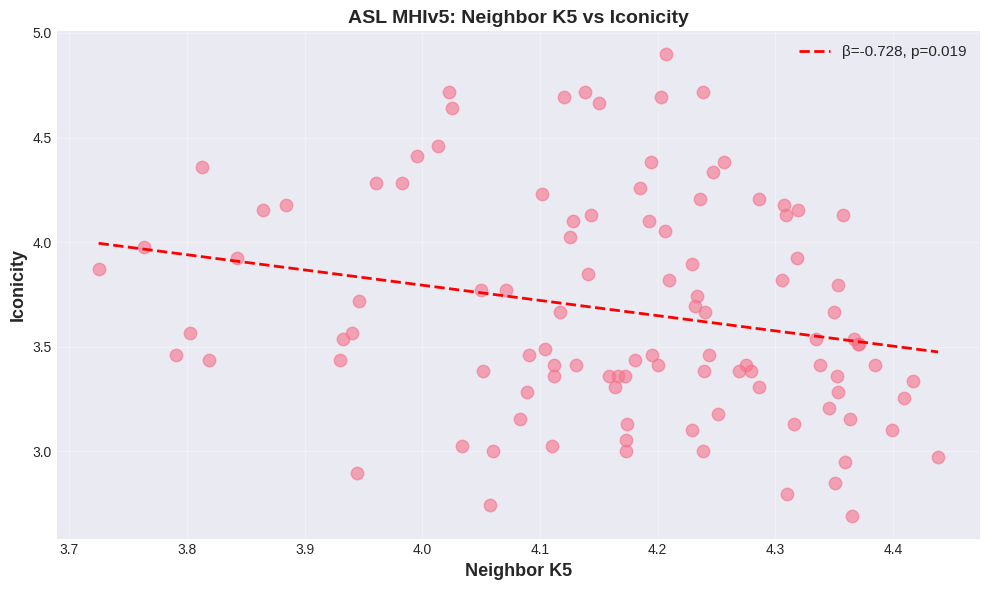


🔹 Métrica: local_concentration
   • β = -0.0123 (📉 NEGATIVO)
   • p-value = 0.0040 (✅ SIGNIFICATIVO)
   • R² = 0.0775
   💡 CONFIRMA HIPÓTESIS: Mayor densidad → Menor iconicidad


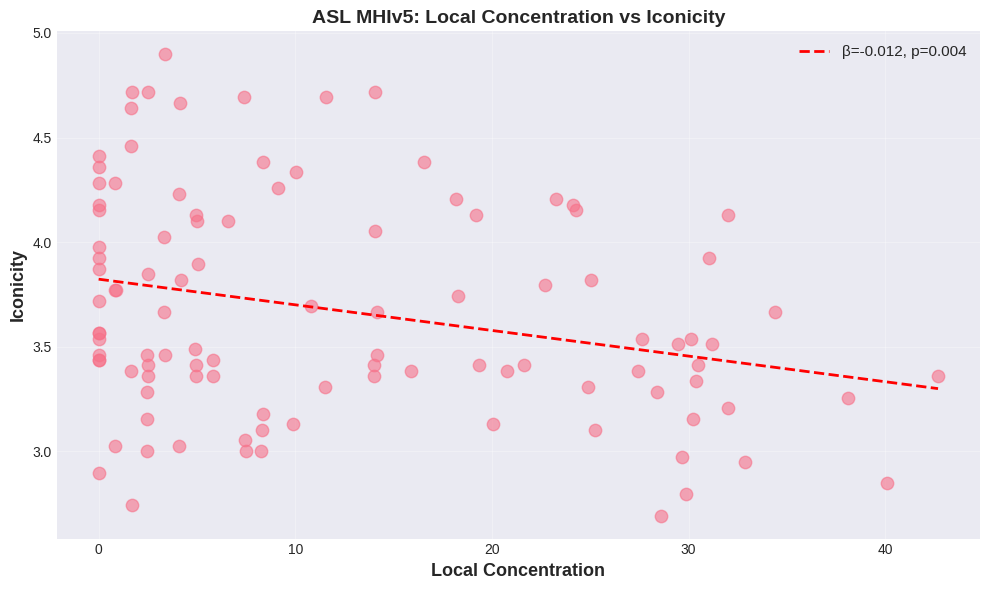


📊 LSP

🔹 Métrica: global_centrality
   • β = 0.0082 (📈 POSITIVO)
   • p-value = 0.0785 (❌ No significativo)
   • R² = 0.0298


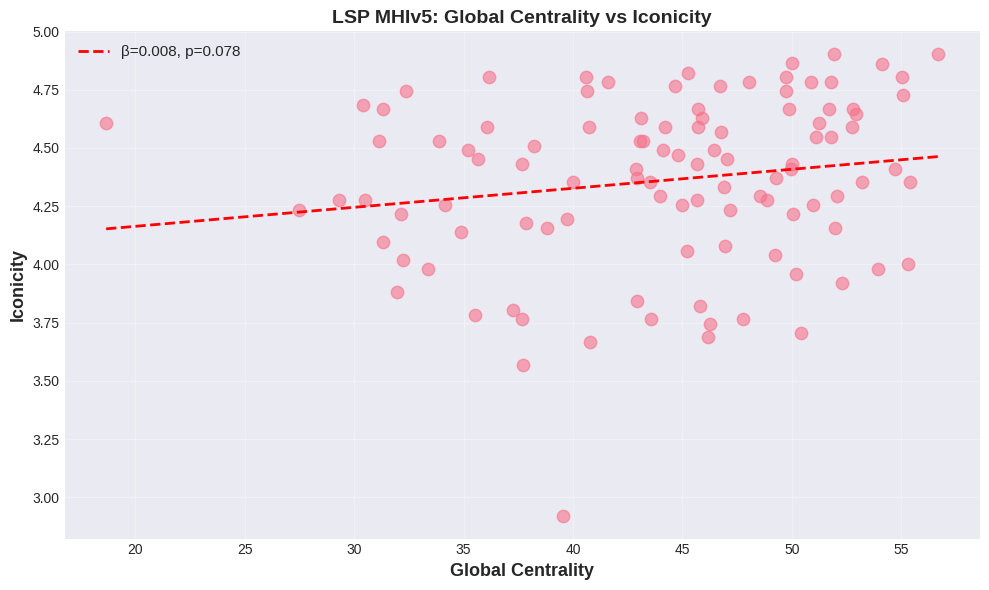


🔹 Métrica: neighbor_k5
   • β = 0.0896 (📈 POSITIVO)
   • p-value = 0.5285 (❌ No significativo)
   • R² = 0.0039


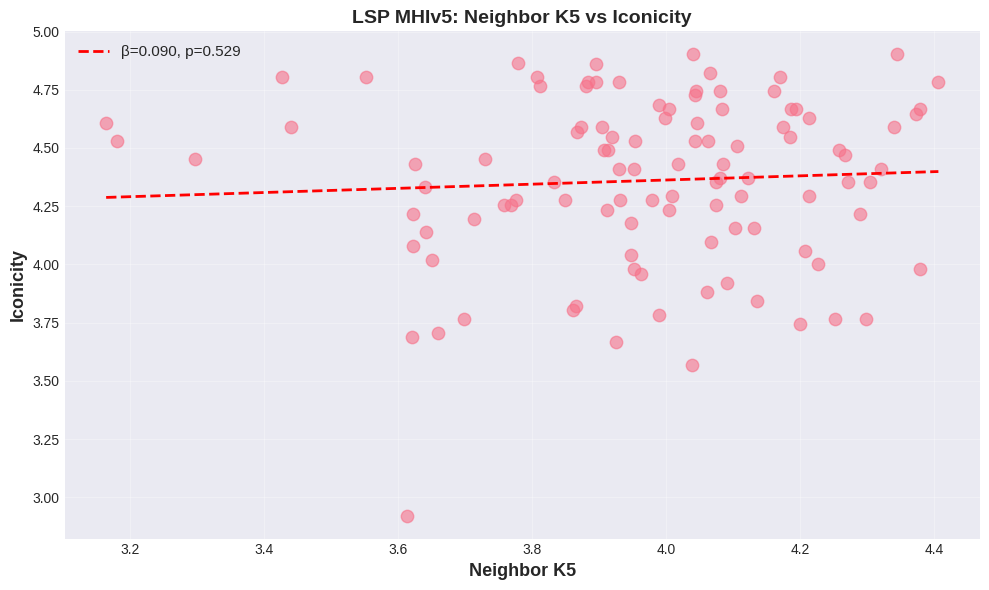


🔹 Métrica: local_concentration
   • β = 0.0053 (📈 POSITIVO)
   • p-value = 0.2797 (❌ No significativo)
   • R² = 0.0113


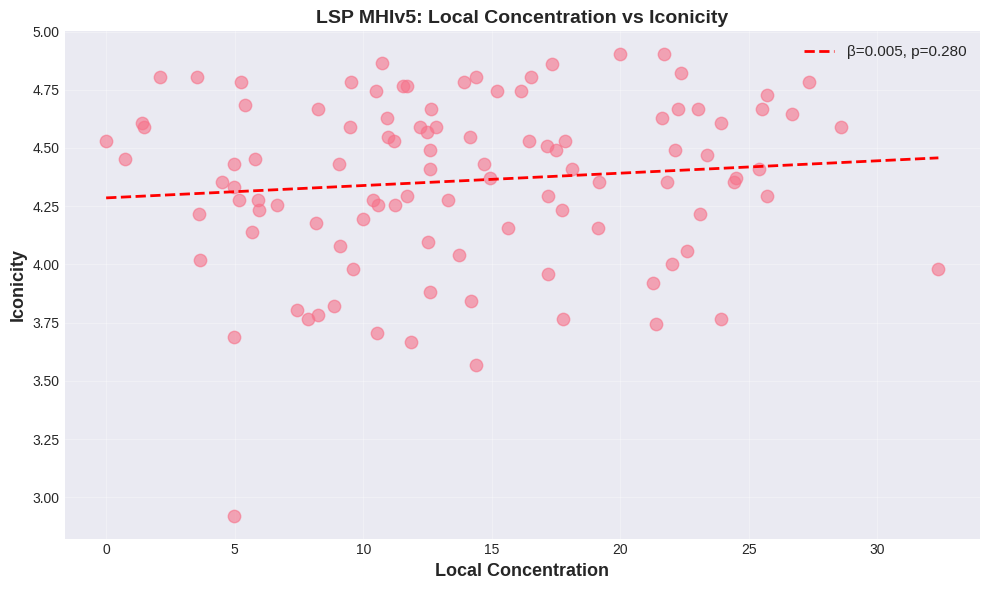


📋 TABLA RESUMEN ASL MHIv5 and LSP MHIv5  


 Language             Measure         β  p-value       R² Significant Direction
ASL-MHIv5   global_centrality -0.034664 0.049925 0.036807           ✅         📉
ASL-MHIv5         neighbor_k5 -0.728443 0.019090 0.052180           ✅         📉
ASL-MHIv5 local_concentration -0.012259 0.004035 0.077492           ✅         📉
LSP-MHIv5   global_centrality  0.008170 0.078452 0.029759           ❌         📈
LSP-MHIv5         neighbor_k5  0.089597 0.528523 0.003868           ❌         📈
LSP-MHIv5 local_concentration  0.005309 0.279741 0.011334           ❌         📈

✅ ETAPA 5 COMPLETADA


In [20]:
# ==============================================================================
# ETAPA 5: DENSIDAD → ICONICIDAD
# ==============================================================================

print("\n" + "="*80)
print("📊 ETAPA 5: ANÁLISIS DENSIDAD → ICONICIDAD")
print("="*80)
print("\nHipótesis Thompson: Densidad ALTA → Iconicidad BAJA (β < 0)")

def analyze_density_iconicity(data, lang_name, iconicityColumn = "iconicity"):
    """Analizar relación densidad-iconicidad"""

    print(f"\n{'='*60}")
    print(f"📊 {lang_name}")
    print(f"{'='*60}")

    results = {}
    #  ['global_centrality', 'neighbor_k5', 'neighbor_k10', 'neighbor_k20','neighbor_k30', 'neighbor_k50', 'local_concentration']
    density_metrics = ['global_centrality', 'neighbor_k5','local_concentration']

    # Ensure iconicity column is numeric, handling potential comma decimals
    if data[iconicityColumn].dtype == 'object':
        try:
            # Use .loc to avoid SettingWithCopyWarning
            data.loc[:, iconicityColumn] = data[iconicityColumn].astype(str).str.replace(',', '.').astype(float)
            print(f"   • Converted '{iconicityColumn}' to numeric for {lang_name}")
        except Exception as e:
            print(f"   ⚠️ Error converting '{iconicityColumn}' to numeric for {lang_name}: {e}")
            return results # Exit if conversion fails

    for metric in density_metrics:
        if metric not in data.columns:
            continue

        print(f"\n🔹 Métrica: {metric}")
        #y = β₀ + β₁*x + error
        #    ↑    ↑
        # const  coeficiente

        #crea la columna de 1s para calcular β₀.
        X = sm.add_constant(data[[metric]])
        #Extrae la columna de iconicidad estandarizada (zscore)
        y = data[iconicityColumn]
        #OLS = Ordinary Least Squares (Mínimos Cuadrados Ordinarios)
        ## OLS encuentra:
          #β₀ = 5.0  (intercepto)
          #β₁ = -0.05  (pendiente)
          # Ecuación resultante:
          #y = 5.0 + (-0.05)*x
          #Cuando densidad = 0 → iconicidad = 5.0 | Por cada unidad que aumenta la densidad → iconicidad disminuye 0.05 (beta)
        model = sm.OLS(y, X).fit()

        #print(model.params) --> const(β₀), metric(β₁)
        #β beta < 0: Relación NEGATIVA  , β beta > 0: Relación POSITIVA
        beta = model.params[metric]
        #La probabilidad de observar estos datos si NO hubiera relación real | p < 0.05 → SIGNIFICATIVO | p ≥ 0.05 →  NO significativo
        p_value = model.pvalues[metric]
        #Proporción de la varianza explicada por el modelo. | R² = 0.80 → El modelo explica 80% de la variabilidad
        #R² > 0.70 → Relación MUY fuerte | R² = 0.30-0.70 → Relación moderada |R² < 0.30 → Relación débil
        r_squared = model.rsquared

        results[metric] = {
            'beta': beta,
            'p_value': p_value,
            'r_squared': r_squared,
            'significant': p_value < 0.05
        }

        sig_marker = "✅ SIGNIFICATIVO" if p_value < 0.05 else "❌ No significativo"
        direction = "📉 NEGATIVO" if beta < 0 else "📈 POSITIVO"

        print(f"   • β = {beta:.4f} ({direction})")
        print(f"   • p-value = {p_value:.4f} ({sig_marker})")
        print(f"   • R² = {r_squared:.4f}")

        if p_value < 0.05:
            if beta < 0:
                print(f"   💡 CONFIRMA HIPÓTESIS: Mayor densidad → Menor iconicidad")
            else:
                print(f"   ⚠️ CONTRADICE HIPÓTESIS: Mayor densidad → Mayor iconicidad")

        # Plot
        plt.figure(figsize=(10, 6))
        plt.scatter(data[metric], data[iconicityColumn], alpha=0.6, s=80)

        x_range = np.linspace(data[metric].min(), data[metric].max(), 100)
        y_pred = model.params[0] + model.params[metric] * x_range
        plt.plot(x_range, y_pred, 'r--', linewidth=2,
                label=f'β={beta:.3f}, p={p_value:.3f}')

        plt.xlabel(metric.replace('_', ' ').title(), fontsize=13, fontweight='bold')
        plt.ylabel(
            'Standardized Iconicity' if standardize else 'Iconicity',
            fontsize=13,
            fontweight='bold'
        )
        plt.title(f'{lang_name} {modelType}: {metric.replace("_", " ").title()} vs Iconicity',
                 fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{analysisType}/{lang_name}_{metric}.png', dpi=300, bbox_inches='tight')
        plt.show()

    return results

if standardize:
  # relacionando con la funcion topFreq, send to analyze_density the top68 instead of the whole asl_data
  results_asl = analyze_density_iconicity(asl_data, "ASL","iconicity_standard")
  results_lsp = analyze_density_iconicity(lsp_data, "LSP","iconicity_standard")
else:
  results_asl = analyze_density_iconicity(asl_data, "ASL")
  results_lsp = analyze_density_iconicity(lsp_data, "LSP")

# Tabla resumen
print("\n" + "="*80)
print(f"📋 TABLA RESUMEN ASL {modelType} and LSP {modelType}  ")
print("="*80)

summary_data = []
for lang, results in [('ASL', results_asl), ('LSP', results_lsp)]:
    for metric, res in results.items():
        summary_data.append({
            'Language': lang + '-' + modelType,
            'Measure': metric,
            'β': res['beta'],
            'p-value': res['p_value'],
            'R²': res['r_squared'],
            'Significant': '✅' if res['significant'] else '❌',
            'Direction': '📉' if res['beta'] < 0 else '📈'
        })

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("✅ ETAPA 5 COMPLETADA")
print("="*80)


In [21]:
# ==============================================================================
# ETAPA 6: FRECUENCIA → ICONICIDAD
# ==============================================================================

print("\n" + "="*80)
print("📊 ETAPA 6: ANÁLISIS FRECUENCIA → ICONICIDAD")
print("="*80)
print("\nHipótesis: Frecuencia ALTA → Iconicidad BAJA (β < 0)")
print("Palabras frecuentes tienden a erosionarse y volverse más arbitrarias")

def analyze_frequency_iconicity(data, lang_name, iconicityColumn="iconicity"):
    """
    Analizar relación frecuencia-iconicidad

    Parámetros:
    -----------
    data : DataFrame
        Datos con columnas 'Frequency' e iconicidad
    lang_name : str
        Nombre del lenguaje (ASL/LSP)
    iconicityColumn : str
        Nombre de la columna de iconicidad (default: "iconicity")

    Returns:
    --------
    dict : Resultados del análisis con beta, p-value, R²
    """

    print(f"\n{'='*60}")
    print(f"📊 {lang_name}")
    print(f"{'='*60}")

    results = {}

    # =========================================================================
    # 1. VERIFICAR COLUMNA 'Frequency'
    # =========================================================================
    if 'frequency' not in data.columns:
        print(f"   ⚠️ ERROR: Columna 'Frequency' no encontrada en {lang_name}")
        print(f"   Columnas disponibles: {', '.join(data.columns)}")
        return results

    print(f"   ✅ Columna 'Frequency' encontrada")

    # =========================================================================
    # 2. LIMPIAR Y CONVERTIR DATOS DE FRECUENCIA
    # =========================================================================
    print(f"\n🔧 Limpieza de datos de frecuencia:")

    # Crear copia para evitar SettingWithCopyWarning
    data = data.copy()

    # Convertir a numérico si es necesario
    if data['frequency'].dtype == 'object':
        try:
            data.loc[:, 'frequency'] = data['frequency'].astype(str).str.replace(',', '.').astype(float)
            print(f"   ✅ Convertido 'Frequency' a numérico")
        except Exception as e:
            print(f"   ⚠️ Error convirtiendo 'Frequency': {e}")
            return results

    # Verificar valores nulos
    n_nulls = data['frequency'].isna().sum()
    if n_nulls > 0:
        print(f"   ⚠️ {n_nulls} valores nulos encontrados - se eliminarán")
        data = data.dropna(subset=['frequency'])
    else:
        print(f"   ✅ No hay valores nulos en 'Frequency'")

    # Verificar valores negativos
    n_negative = (data['frequency'] < 0).sum()
    if n_negative > 0:
        print(f"   ⚠️ {n_negative} valores negativos encontrados - se eliminarán")
        data = data[data['frequency'] >= 0]

    # =========================================================================
    # 3. ESTADÍSTICAS DESCRIPTIVAS DE FRECUENCIA
    # =========================================================================
    print(f"\n📊 Estadísticas de Frecuencia:")
    print(f"   • N = {len(data)}")
    print(f"   • Media = {data['frequency'].mean():.2f}")
    print(f"   • Mediana = {data['frequency'].median():.2f}")
    print(f"   • Min = {data['frequency'].min():.0f}")
    print(f"   • Max = {data['frequency'].max():.0f}")
    print(f"   • Desv. Est. = {data['frequency'].std():.2f}")
    print(f"   • Q1 = {data['frequency'].quantile(0.25):.2f}")
    print(f"   • Q3 = {data['frequency'].quantile(0.75):.2f}")

    # =========================================================================
    # 4. PREPARAR DATOS DE ICONICIDAD
    # =========================================================================
    if iconicityColumn not in data.columns:
        print(f"   ⚠️ ERROR: Columna '{iconicityColumn}' no encontrada")
        return results

    # Convertir iconicidad a numérico si es necesario
    if data[iconicityColumn].dtype == 'object':
        try:
            data.loc[:, iconicityColumn] = data[iconicityColumn].astype(str).str.replace(',', '.').astype(float)
            print(f"   ✅ Convertido '{iconicityColumn}' a numérico")
        except Exception as e:
            print(f"   ⚠️ Error convirtiendo '{iconicityColumn}': {e}")
            return results

    # Eliminar nulos en iconicidad
    n_nulls_icon = data[iconicityColumn].isna().sum()
    if n_nulls_icon > 0:
        print(f"   ⚠️ {n_nulls_icon} valores nulos en iconicidad - se eliminarán")
        data = data.dropna(subset=[iconicityColumn])

    if len(data) == 0:
        print(f"   ⚠️ ERROR: No hay datos válidos después de la limpieza")
        return results

    # =========================================================================
    # 5. REGRESIÓN OLS: Iconicidad ~ Frecuencia
    # =========================================================================
    print(f"\n🔹 Análisis de regresión: Frequency → {iconicityColumn}")

    # y = β₀ + β₁*Frequency + error
    # β₁ < 0 → Mayor frecuencia, menor iconicidad (confirma hipótesis)
    # β₁ > 0 → Mayor frecuencia, mayor iconicidad (contradice hipótesis)

    X = sm.add_constant(data[['frequency']])
    y = data[iconicityColumn]
    model = sm.OLS(y, X).fit()

    # Extraer parámetros
    beta = model.params['frequency']
    p_value = model.pvalues['frequency']
    r_squared = model.rsquared

    # Guardar resultados
    results['frequency'] = {
        'beta': beta,
        'p_value': p_value,
        'r_squared': r_squared,
        'significant': p_value < 0.05,
        'n': len(data)
    }

    # =========================================================================
    # 6. INTERPRETACIÓN DE RESULTADOS
    # =========================================================================
    sig_marker = "✅ SIGNIFICATIVO" if p_value < 0.05 else "❌ No significativo"
    direction = "📉 NEGATIVO" if beta < 0 else "📈 POSITIVO"

    print(f"   • β = {beta:.6f} ({direction})")
    print(f"   • p-value = {p_value:.6f} ({sig_marker})")
    print(f"   • R² = {r_squared:.4f}")

    # Interpretación de R²
    if r_squared > 0.70:
        r2_interpretation = "MUY fuerte"
    elif r_squared >= 0.30:
        r2_interpretation = "moderada"
    else:
        r2_interpretation = "débil"
    print(f"   • Relación: {r2_interpretation}")

    # Verificar hipótesis
    print(f"\n   📋 Verificación de hipótesis:")
    if p_value < 0.05:
        if beta < 0:
            print(f"   💡 ✅ CONFIRMA HIPÓTESIS: Mayor frecuencia → Menor iconicidad")
            print(f"   Interpretación: Por cada aumento de 1 en frecuencia,")
            print(f"   la iconicidad disminuye en {abs(beta):.6f} unidades")
        else:
            print(f"   ⚠️ ❌ CONTRADICE HIPÓTESIS: Mayor frecuencia → Mayor iconicidad")
            print(f"   Interpretación: Por cada aumento de 1 en frecuencia,")
            print(f"   la iconicidad aumenta en {beta:.6f} unidades")
    else:
        print(f"   ℹ️ No hay evidencia estadísticamente significativa de relación")
        print(f"   (p-value = {p_value:.6f} ≥ 0.05)")

    # =========================================================================
    # 7. VISUALIZACIÓN
    # =========================================================================
    plt.figure(figsize=(10, 6))

    # Scatter plot
    # plt.scatter(data['frequency'], data[iconicityColumn],
    #             alpha=0.6, s=80, edgecolors='black', linewidth=0.5,
    #             color='steelblue')

    plt.scatter(data['frequency'], data[iconicityColumn],
                alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

    # Línea de regresión
    x_range = np.linspace(data['frequency'].min(), data['frequency'].max(), 100)
    y_pred = model.params['const'] + model.params['frequency'] * x_range

    # Color de línea según dirección
    # line_color = 'red' if beta < 0 else 'green'

    # plt.plot(x_range, y_pred, '--', linewidth=2, color=line_color,
    #         label=f'β={beta:.6f}, p={p_value:.4f}, R²={r_squared:.3f}')

    plt.plot(x_range, y_pred, '--', linewidth=2,
            label=f'β={beta:.6f}, p={p_value:.4f}, R²={r_squared:.3f}')

    # Etiquetas y título
    plt.xlabel('Frequency (Absolute Count)', fontsize=13, fontweight='bold')
    plt.ylabel(iconicityColumn.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    plt.title(f'{lang_name}: Frequency vs Iconicity',
             fontsize=14, fontweight='bold')

    # Leyenda mejorada
    legend_text = f'β={beta:.6f}, p={p_value:.4f}, R²={r_squared:.3f}'
    plt.legend([legend_text], fontsize=10, loc='best', framealpha=0.9)

    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()

    # Guardar gráfico
    filename = f'{analysisType}/{lang_name}_Frequency_Iconicity.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n   💾 Gráfico guardado: {filename}")
    plt.show()

    return results


# ==============================================================================
# EJECUTAR ANÁLISIS PARA ASL Y LSP
# ==============================================================================

# Determinar columna de iconicidad según variable 'standardize'
if standardize:
    iconicity_col = "iconicity_standard"
    print(f"\n📌 Usando iconicidad estandarizada: {iconicity_col}")
else:
    iconicity_col = "iconicity"
    print(f"\n📌 Usando iconicidad original: {iconicity_col}")

# Analizar ASL
print("\n" + "▼"*80)
results_freq_asl = analyze_frequency_iconicity(asl_data, "ASL", iconicity_col)

# Analizar LSP
print("\n" + "▼"*80)
results_freq_lsp = analyze_frequency_iconicity(lsp_data, "LSP", iconicity_col)


# ==============================================================================
# TABLA RESUMEN COMPARATIVA
# ==============================================================================

print("\n" + "="*80)
print("📋 TABLA RESUMEN - FRECUENCIA vs ICONICIDAD")
print("="*80)

summary_freq_data = []
for lang, results in [('ASL', results_freq_asl), ('LSP', results_freq_lsp)]:
    if 'frequency' in results:
        res = results['frequency']

        # Determinar si confirma hipótesis
        confirms_hypothesis = (res['significant'] and res['beta'] < 0)

        summary_freq_data.append({
            'Lengua': lang,
            'N': res['n'],
            'β (Beta)': f"{res['beta']:.6f}",
            'p-value': f"{res['p_value']:.6f}",
            'R²': f"{res['r_squared']:.4f}",
            'Significativo': '✅ Sí' if res['significant'] else '❌ No',
            'Dirección': '📉 Negativo' if res['beta'] < 0 else '📈 Positivo',
            'Confirma Hipótesis': '✅ Sí' if confirms_hypothesis else '❌ No'
        })

if summary_freq_data:
    summary_freq_df = pd.DataFrame(summary_freq_data)
    print("\n")
    print(summary_freq_df.to_string(index=False))

    # Exportar tabla
    csv_filename = f'{analysisType}/Resumen_Frecuencia_Iconicidad.csv'
    summary_freq_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    print(f"\n💾 Tabla guardada: {csv_filename}")
else:
    print("\n⚠️ No hay datos para mostrar en la tabla resumen")

# ==============================================================================
# COMPARACIÓN ENTRE ASL Y LSP
# ==============================================================================

print("\n" + "="*80)
print("🔍 COMPARACIÓN ASL vs LSP")
print("="*80)

if results_freq_asl and results_freq_lsp:
    if 'frequency' in results_freq_asl and 'frequency' in results_freq_lsp:
        asl_res = results_freq_asl['frequency']
        lsp_res = results_freq_lsp['frequency']

        print("\n📊 Coeficientes Beta:")
        print(f"   • ASL: β = {asl_res['beta']:.6f}")
        print(f"   • LSP: β = {lsp_res['beta']:.6f}")
        print(f"   • Diferencia: {abs(asl_res['beta'] - lsp_res['beta']):.6f}")

        print("\n📊 Significancia:")
        print(f"   • ASL: p = {asl_res['p_value']:.6f} {'✅' if asl_res['significant'] else '❌'}")
        print(f"   • LSP: p = {lsp_res['p_value']:.6f} {'✅' if lsp_res['significant'] else '❌'}")

        print("\n📊 Poder Explicativo (R²):")
        print(f"   • ASL: R² = {asl_res['r_squared']:.4f}")
        print(f"   • LSP: R² = {lsp_res['r_squared']:.4f}")

        # Determinar cuál tiene efecto más fuerte
        if asl_res['significant'] and lsp_res['significant']:
            if abs(asl_res['beta']) > abs(lsp_res['beta']):
                print(f"\n   💡 ASL muestra un efecto más fuerte de frecuencia sobre iconicidad")
            elif abs(lsp_res['beta']) > abs(asl_res['beta']):
                print(f"\n   💡 LSP muestra un efecto más fuerte de frecuencia sobre iconicidad")
            else:
                print(f"\n   💡 Ambos lenguajes muestran efectos similares")
        elif asl_res['significant']:
            print(f"\n   💡 Solo ASL muestra una relación significativa")
        elif lsp_res['significant']:
            print(f"\n   💡 Solo LSP muestra una relación significativa")
        else:
            print(f"\n   ℹ️ Ningún lenguaje muestra una relación significativa")

print("\n" + "="*80)
print("✅ ETAPA 6 COMPLETADA")
print("="*80)


📊 ETAPA 6: ANÁLISIS FRECUENCIA → ICONICIDAD

Hipótesis: Frecuencia ALTA → Iconicidad BAJA (β < 0)
Palabras frecuentes tienden a erosionarse y volverse más arbitrarias

📌 Usando iconicidad original: iconicity

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

📊 ASL
   ⚠️ ERROR: Columna 'Frequency' no encontrada en ASL
   Columnas disponibles: word, iconicity, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 1

In [22]:
# ==============================================================================
# ETAPA 6B: ANOVA - FRECUENCIA CATEGORIZADA → ICONICIDAD
# ==============================================================================

print("\n" + "="*80)
print("📊 ETAPA 6B: ANOVA - FRECUENCIA CATEGORIZADA → ICONICIDAD")
print("="*80)
print("\nHipótesis: Existen diferencias significativas en iconicidad")
print("           entre grupos de palabras con diferente frecuencia")
print("\nMetodología: One-Way ANOVA + Tests Post-Hoc (Tukey HSD)")

# ==============================================================================
# IMPORTAR LIBRERÍAS ADICIONALES PARA ANOVA
# ==============================================================================

from scipy import stats
from scipy.stats import shapiro, levene, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns

# ==============================================================================
# FUNCIÓN PRINCIPAL: ANÁLISIS ANOVA
# ==============================================================================

def analyze_frequency_iconicity_anova(data, lang_name, iconicityColumn="iconicity"):
    """
    Analizar diferencias en iconicidad entre grupos de frecuencia usando ANOVA

    Parámetros:
    -----------
    data : DataFrame
        Datos con columnas 'frequency' e iconicidad
    lang_name : str
        Nombre del lenguaje (ASL/LSP)
    iconicityColumn : str
        Nombre de la columna de iconicidad

    Returns:
    --------
    dict : Resultados completos del análisis ANOVA
    """

    print(f"\n{'='*60}")
    print(f"📊 {lang_name}")
    print(f"{'='*60}")

    results = {
        'lang': lang_name,
        'n_total': len(data)
    }

    # =========================================================================
    # PASO 1: VERIFICAR COLUMNAS NECESARIAS
    # =========================================================================
    if 'frequency' not in data.columns:
        print(f"   ⚠️ ERROR: Columna 'frequency' no encontrada en {lang_name}")
        return results

    if iconicityColumn not in data.columns:
        print(f"   ⚠️ ERROR: Columna '{iconicityColumn}' no encontrada en {lang_name}")
        return results

    print(f"   ✅ Columnas requeridas encontradas")

    # =========================================================================
    # PASO 2: LIMPIAR DATOS
    # =========================================================================
    print(f"\n🔧 Limpieza de datos:")

    # Crear copia
    data = data.copy()

    # Convertir a numérico si es necesario
    if data['frequency'].dtype == 'object':
        data['frequency'] = pd.to_numeric(data['frequency'], errors='coerce')

    if data[iconicityColumn].dtype == 'object':
        data[iconicityColumn] = pd.to_numeric(data[iconicityColumn], errors='coerce')

    # Eliminar nulos
    n_before = len(data)
    data = data.dropna(subset=['frequency', iconicityColumn])
    n_after = len(data)

    if n_before > n_after:
        print(f"   ⚠️ {n_before - n_after} filas eliminadas por valores nulos")

    # Eliminar valores negativos de frecuencia
    n_before = len(data)
    data = data[data['frequency'] >= 0]
    n_after = len(data)

    if n_before > n_after:
        print(f"   ⚠️ {n_before - n_after} filas eliminadas por frecuencias negativas")

    print(f"   ✅ N final = {len(data)}")

    if len(data) < 20:
        print(f"   ⚠️ ERROR: Muy pocos datos para análisis ANOVA")
        return results

    results['n_clean'] = len(data)

    # =========================================================================
    # PASO 3: CATEGORIZAR FRECUENCIA EN CUARTILES
    # =========================================================================
    print(f"\n📊 PASO 1: Categorización en Cuartiles")
    print(f"{'─'*60}")

    # Calcular cuartiles
    Q1 = data['frequency'].quantile(0.25)
    Q2 = data['frequency'].quantile(0.50)
    Q3 = data['frequency'].quantile(0.75)

    print(f"   • Q1 (25%) = {Q1:.2f}")
    print(f"   • Q2 (50%) = {Q2:.2f}")
    print(f"   • Q3 (75%) = {Q3:.2f}")

    # Crear grupos
    def categorize_frequency(freq):
        if freq <= Q1:
            return "MUY BAJA"
        elif freq <= Q2:
            return "BAJA"
        elif freq <= Q3:
            return "ALTA"
        else:
            return "MUY ALTA"

    data['FrequencyGroup'] = data['frequency'].apply(categorize_frequency)

    # Ordenar categorías
    category_order = ["MUY BAJA", "BAJA", "ALTA", "MUY ALTA"]
    data['FrequencyGroup'] = pd.Categorical(data['FrequencyGroup'],
                                            categories=category_order,
                                            ordered=True)

    # Estadísticas por grupo
    print(f"\n   📋 Estadísticas por Grupo:")
    print(f"   {'─'*56}")
    print(f"   {'Grupo':<12} {'N':>6} {'Freq_Min':>10} {'Freq_Max':>10} {'Icon_Mean':>10} {'Icon_SD':>8}")
    print(f"   {'─'*56}")

    group_stats = []
    for group in category_order:
        group_data = data[data['FrequencyGroup'] == group]
        if len(group_data) > 0:
            stats_row = {
                'group': group,
                'n': len(group_data),
                'freq_min': group_data['frequency'].min(),
                'freq_max': group_data['frequency'].max(),
                'icon_mean': group_data[iconicityColumn].mean(),
                'icon_sd': group_data[iconicityColumn].std()
            }
            group_stats.append(stats_row)

            print(f"   {group:<12} {stats_row['n']:>6} "
                  f"{stats_row['freq_min']:>10.0f} {stats_row['freq_max']:>10.0f} "
                  f"{stats_row['icon_mean']:>10.3f} {stats_row['icon_sd']:>8.3f}")

    results['group_stats'] = group_stats
    results['quartiles'] = {'Q1': Q1, 'Q2': Q2, 'Q3': Q3}

    # =========================================================================
    # PASO 4: VERIFICAR SUPUESTOS ESTADÍSTICOS
    # =========================================================================
    print(f"\n📊 PASO 2: Verificación de Supuestos Estadísticos")
    print(f"{'─'*60}")

    # 4.1 Test de Normalidad (Shapiro-Wilk)
    print(f"\n   🔬 Test de Normalidad (Shapiro-Wilk)")
    print(f"   H0: Los datos siguen distribución normal")
    print(f"   Criterio: p-value > 0.05 → Normalidad OK ✅")
    print(f"\n   {'Grupo':<12} {'W-statistic':>13} {'p-value':>10} {'Normal?':>10}")
    print(f"   {'─'*47}")

    normality_results = {}
    all_normal = True

    for group in category_order:
        group_data = data[data['FrequencyGroup'] == group][iconicityColumn]
        if len(group_data) >= 3:  # Shapiro requiere al menos 3 observaciones
            w_stat, p_val = shapiro(group_data)
            is_normal = p_val > 0.05
            normality_results[group] = {'w_stat': w_stat, 'p_value': p_val, 'normal': is_normal}

            status = "✅ Sí" if is_normal else "❌ No"
            all_normal = all_normal and is_normal

            print(f"   {group:<12} {w_stat:>13.4f} {p_val:>10.4f} {status:>10}")
        else:
            print(f"   {group:<12} {'N/A':>13} {'N/A':>10} {'N/A':>10}")
            normality_results[group] = {'w_stat': None, 'p_value': None, 'normal': None}

    results['normality'] = normality_results
    results['all_normal'] = all_normal

    if all_normal:
        print(f"\n   ✅ Supuesto de normalidad cumplido en todos los grupos")
    else:
        print(f"\n   ⚠️ Supuesto de normalidad NO cumplido en algunos grupos")
        print(f"   → ANOVA es robusta a violaciones moderadas")
        print(f"   → Se ejecutará también Kruskal-Wallis (no paramétrico)")

    # 4.2 Test de Homogeneidad de Varianzas (Levene)
    print(f"\n   🔬 Test de Levene (Homogeneidad de Varianzas)")
    print(f"   H0: Las varianzas son iguales entre grupos")
    print(f"   Criterio: p-value > 0.05 → Homogeneidad OK ✅")

    # Preparar datos para Levene
    groups_for_levene = [data[data['FrequencyGroup'] == g][iconicityColumn].values
                         for g in category_order
                         if len(data[data['FrequencyGroup'] == g]) > 0]

    if len(groups_for_levene) >= 2:
        levene_stat, levene_p = levene(*groups_for_levene)
        homogeneity_ok = levene_p > 0.05

        print(f"\n   Levene statistic = {levene_stat:.4f}")
        print(f"   p-value = {levene_p:.4f}")

        if homogeneity_ok:
            print(f"\n   ✅ Supuesto de homogeneidad de varianzas cumplido")
        else:
            print(f"\n   ⚠️ Supuesto de homogeneidad de varianzas NO cumplido")
            print(f"   → Se puede usar ANOVA (robusta) o Welch's ANOVA")

        results['levene'] = {'statistic': levene_stat, 'p_value': levene_p, 'homogeneous': homogeneity_ok}
    else:
        print(f"\n   ⚠️ No hay suficientes grupos para test de Levene")
        homogeneity_ok = None
        results['levene'] = None

    # =========================================================================
    # PASO 5: ONE-WAY ANOVA
    # =========================================================================
    print(f"\n📊 PASO 3: One-Way ANOVA")
    print(f"{'─'*60}")
    print(f"   Variable independiente: FrequencyGroup (4 niveles)")
    print(f"   Variable dependiente: {iconicityColumn}")

    # Preparar datos para ANOVA
    groups_for_anova = [data[data['FrequencyGroup'] == g][iconicityColumn].values
                        for g in category_order
                        if len(data[data['FrequencyGroup'] == g]) > 0]

    if len(groups_for_anova) >= 2:
        # Ejecutar ANOVA
        f_stat, p_value = stats.f_oneway(*groups_for_anova)

        # Calcular tamaño del efecto (η² - eta cuadrado)
        # η² = SS_between / SS_total
        grand_mean = data[iconicityColumn].mean()
        ss_between = sum([len(data[data['FrequencyGroup'] == g]) *
                         (data[data['FrequencyGroup'] == g][iconicityColumn].mean() - grand_mean)**2
                         for g in category_order
                         if len(data[data['FrequencyGroup'] == g]) > 0])

        ss_total = sum((data[iconicityColumn] - grand_mean)**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0

        # Grados de libertad
        df_between = len(groups_for_anova) - 1
        df_within = len(data) - len(groups_for_anova)
        df_total = len(data) - 1

        # Suma de cuadrados
        ss_within = ss_total - ss_between

        # Media de cuadrados
        ms_between = ss_between / df_between if df_between > 0 else 0
        ms_within = ss_within / df_within if df_within > 0 else 0

        # Resultados
        results['anova'] = {
            'f_statistic': f_stat,
            'p_value': p_value,
            'eta_squared': eta_squared,
            'df_between': df_between,
            'df_within': df_within,
            'df_total': df_total,
            'ss_between': ss_between,
            'ss_within': ss_within,
            'ss_total': ss_total,
            'ms_between': ms_between,
            'ms_within': ms_within,
            'significant': p_value < 0.05
        }

        # Imprimir tabla ANOVA
        print(f"\n   {'Source':<15} {'SS':>12} {'df':>6} {'MS':>12} {'F':>10} {'p-value':>12}")
        print(f"   {'─'*67}")
        print(f"   {'Between Groups':<15} {ss_between:>12.3f} {df_between:>6} {ms_between:>12.3f} {f_stat:>10.3f} {p_value:>12.6f}")
        print(f"   {'Within Groups':<15} {ss_within:>12.3f} {df_within:>6} {ms_within:>12.3f}")
        print(f"   {'Total':<15} {ss_total:>12.3f} {df_total:>6}")

        # Interpretación
        sig_stars = ""
        if p_value < 0.001:
            sig_stars = "***"
        elif p_value < 0.01:
            sig_stars = "**"
        elif p_value < 0.05:
            sig_stars = "*"

        print(f"\n   F({df_between}, {df_within}) = {f_stat:.3f}, p = {p_value:.6f} {sig_stars}")
        print(f"   η² = {eta_squared:.4f} ", end="")

        # Interpretación del tamaño del efecto
        if eta_squared < 0.01:
            effect_size = "trivial"
        elif eta_squared < 0.06:
            effect_size = "pequeño"
        elif eta_squared < 0.14:
            effect_size = "moderado"
        else:
            effect_size = "grande"

        print(f"(efecto {effect_size})")

        if p_value < 0.05:
            print(f"\n   ✅ RESULTADO SIGNIFICATIVO")
            print(f"   Conclusión: Existen diferencias significativas en iconicidad")
            print(f"              entre los grupos de frecuencia")
        else:
            print(f"\n   ❌ RESULTADO NO SIGNIFICATIVO")
            print(f"   Conclusión: No hay evidencia de diferencias significativas")
            print(f"              en iconicidad entre grupos de frecuencia")

    else:
        print(f"\n   ⚠️ ERROR: No hay suficientes grupos para ANOVA")
        results['anova'] = None
        return results

    # =========================================================================
    # PASO 6: TESTS POST-HOC (Tukey HSD)
    # =========================================================================
    if results['anova']['significant']:
        print(f"\n📊 PASO 4: Tests Post-Hoc (Tukey HSD)")
        print(f"{'─'*60}")
        print(f"   Comparaciones múltiples por pares")
        print(f"   Criterio: p-value ajustado < 0.05 → Diferencia significativa")

        # Ejecutar Tukey HSD
        tukey = pairwise_tukeyhsd(endog=data[iconicityColumn],
                                  groups=data['FrequencyGroup'],
                                  alpha=0.05)

        # Convertir resultados a DataFrame
        tukey_df = pd.DataFrame(data=tukey.summary().data[1:],
                               columns=tukey.summary().data[0])

        results['tukey'] = tukey_df

        # Imprimir resultados
        print(f"\n   {'Comparación':<25} {'Diff':>8} {'Lower':>8} {'Upper':>8} {'p-adj':>10} {'Sig?':>6}")
        print(f"   {'─'*67}")

        for idx, row in tukey_df.iterrows():
            group1 = row['group1']
            group2 = row['group2']
            diff = row['meandiff']
            lower = row['lower']
            upper = row['upper']
            p_adj = row['p-adj']
            reject = row['reject']

            comparison = f"{group1} vs {group2}"
            sig_marker = "✅" if reject else "❌"

            if reject:
                if p_adj < 0.001:
                    sig_stars = "***"
                elif p_adj < 0.01:
                    sig_stars = "**"
                else:
                    sig_stars = "*"
            else:
                sig_stars = "ns"

            print(f"   {comparison:<25} {diff:>8.3f} {lower:>8.3f} {upper:>8.3f} {p_adj:>10.4f} {sig_marker:>3} {sig_stars:>2}")

        # Interpretación
        print(f"\n   📋 Interpretación Post-Hoc:")

        # Encontrar grupo con mayor y menor iconicidad
        group_means = {g: data[data['FrequencyGroup'] == g][iconicityColumn].mean()
                       for g in category_order}
        max_group = max(group_means, key=group_means.get)
        min_group = min(group_means, key=group_means.get)

        print(f"   • Grupo con MAYOR iconicidad: {max_group} (μ = {group_means[max_group]:.3f})")
        print(f"   • Grupo con MENOR iconicidad: {min_group} (μ = {group_means[min_group]:.3f})")

        # Verificar tendencia
        if group_means["MUY BAJA"] > group_means["MUY ALTA"]:
            print(f"   • Tendencia: ↓ A mayor frecuencia → Menor iconicidad")
            print(f"   ✅ CONFIRMA HIPÓTESIS: Palabras frecuentes tienen menor iconicidad")
        else:
            print(f"   • Tendencia: ↑ A mayor frecuencia → Mayor iconicidad")
            print(f"   ⚠️ CONTRADICE HIPÓTESIS")

        results['group_means'] = group_means
        results['max_group'] = max_group
        results['min_group'] = min_group

    else:
        print(f"\n   ℹ️ Tests Post-Hoc no necesarios (ANOVA no significativa)")
        results['tukey'] = None

    # =========================================================================
    # PASO 7: KRUSKAL-WALLIS (si supuestos fallan)
    # =========================================================================
    if not all_normal or (homogeneity_ok is not None and not homogeneity_ok):
        print(f"\n📊 PASO 5: Kruskal-Wallis Test (Alternativa No Paramétrica)")
        print(f"{'─'*60}")
        print(f"   ⚠️ Ejecutando prueba no paramétrica debido a:")
        if not all_normal:
            print(f"      - Violación del supuesto de normalidad")
        if homogeneity_ok is not None and not homogeneity_ok:
            print(f"      - Violación del supuesto de homogeneidad de varianzas")

        # Ejecutar Kruskal-Wallis
        h_stat, kw_p_value = kruskal(*groups_for_anova)

        results['kruskal_wallis'] = {
            'h_statistic': h_stat,
            'p_value': kw_p_value,
            'significant': kw_p_value < 0.05
        }

        print(f"\n   H-statistic = {h_stat:.4f}")
        print(f"   p-value = {kw_p_value:.6f}")

        if kw_p_value < 0.05:
            print(f"\n   ✅ Resultado SIGNIFICATIVO (no paramétrico)")
            if results['anova']['significant']:
                print(f"   ✅ Confirma hallazgos de ANOVA paramétrica")
            else:
                print(f"   ⚠️ Resultado diferente a ANOVA paramétrica")
        else:
            print(f"\n   ❌ Resultado NO SIGNIFICATIVO (no paramétrico)")
    else:
        print(f"\n   ℹ️ Kruskal-Wallis no necesario (supuestos cumplidos)")
        results['kruskal_wallis'] = None

    # =========================================================================
    # PASO 8: VISUALIZACIONES
    # =========================================================================
    print(f"\n📊 PASO 6: Generando Visualizaciones")
    print(f"{'─'*60}")

    # 8.1 BOXPLOT
    print(f"   🎨 Generando Boxplot...")
    plt.figure(figsize=(12, 7))

    # Crear boxplot con seaborn
    sns.boxplot(data=data, x='FrequencyGroup', y=iconicityColumn,
                palette='Set2', order=category_order)

    # Añadir puntos individuales con jitter
    sns.stripplot(data=data, x='FrequencyGroup', y=iconicityColumn,
                  color='black', alpha=0.3, size=3, order=category_order)

    # Título con resultados
    if results['anova']['significant']:
        title = f"{lang_name}: Iconicidad por Grupo de Frecuencia\n"
        title += f"F({results['anova']['df_between']},{results['anova']['df_within']}) = "
        title += f"{results['anova']['f_statistic']:.2f}, p = {results['anova']['p_value']:.4f}"

        if results['anova']['p_value'] < 0.001:
            title += " ***"
        elif results['anova']['p_value'] < 0.01:
            title += " **"
        elif results['anova']['p_value'] < 0.05:
            title += " *"
    else:
        title = f"{lang_name}: Iconicidad por Grupo de Frecuencia\n"
        title += f"F = {results['anova']['f_statistic']:.2f}, p = {results['anova']['p_value']:.4f} (ns)"

    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Grupo de Frecuencia', fontsize=12, fontweight='bold')
    plt.ylabel(iconicityColumn.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()

    filename = f'{analysisType}/{lang_name}_ANOVA_Boxplot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"      ✅ Guardado: {filename}")
    plt.show()

    # 8.2 VIOLIN PLOT
    print(f"   🎨 Generando Violin Plot...")
    plt.figure(figsize=(12, 7))

    # Crear violin plot
    sns.violinplot(data=data, x='FrequencyGroup', y=iconicityColumn,
                   palette='Set3', order=category_order, inner='box')

    # Título
    plt.title(f"{lang_name}: Distribución de Iconicidad por Grupo de Frecuencia\n" +
              f"η² = {results['anova']['eta_squared']:.4f}",
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Grupo de Frecuencia', fontsize=12, fontweight='bold')
    plt.ylabel(iconicityColumn.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()

    filename = f'{analysisType}/{lang_name}_ANOVA_Violinplot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"      ✅ Guardado: {filename}")
    plt.show()

    # 8.3 BARPLOT CON MEDIAS Y ERROR BARS
    print(f"   🎨 Generando Barplot con Medias...")

    # Calcular medias y CI
    group_data = []
    for group in category_order:
        g_data = data[data['FrequencyGroup'] == group][iconicityColumn]
        if len(g_data) > 0:
            mean = g_data.mean()
            sem = g_data.sem()  # Standard error of mean
            ci = 1.96 * sem  # 95% CI
            group_data.append({
                'group': group,
                'mean': mean,
                'ci': ci
            })

    # Crear barplot
    fig, ax = plt.subplots(figsize=(12, 7))

    groups = [d['group'] for d in group_data]
    means = [d['mean'] for d in group_data]
    cis = [d['ci'] for d in group_data]

    x_pos = np.arange(len(groups))
    bars = ax.bar(x_pos, means, yerr=cis, capsize=8,
                   alpha=0.7, color=['#8dd3c7', '#ffffb3', '#bebada', '#fb8072'])

    # Añadir valores sobre las barras
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + cis[i],
                f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

    # Añadir líneas de significancia post-hoc si están disponibles
    if results.get('tukey') is not None and results['anova']['significant']:
        y_max = max(means) + max(cis)
        y_range = max(means) - min(means)
        offset = 0.05 * y_range

        # Solo marcar las comparaciones más relevantes para no saturar
        significant_comparisons = results['tukey'][results['tukey']['reject'] == True]

        # Límite de comparaciones a mostrar
        n_comparisons_shown = 0
        max_comparisons_to_show = 3

        for idx, row in significant_comparisons.iterrows():
            if n_comparisons_shown >= max_comparisons_to_show:
                break

            group1_idx = category_order.index(row['group1'])
            group2_idx = category_order.index(row['group2'])

            # Solo mostrar comparaciones entre grupos no adyacentes
            if abs(group1_idx - group2_idx) > 1:
                y_level = y_max + offset * (n_comparisons_shown + 1)

                ax.plot([group1_idx, group2_idx], [y_level, y_level],
                       'k-', linewidth=1.5)

                if row['p-adj'] < 0.001:
                    sig_text = '***'
                elif row['p-adj'] < 0.01:
                    sig_text = '**'
                else:
                    sig_text = '*'

                ax.text((group1_idx + group2_idx) / 2, y_level, sig_text,
                       ha='center', va='bottom', fontsize=12, fontweight='bold')

                n_comparisons_shown += 1

    ax.set_xlabel('Grupo de Frecuencia', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Media de {iconicityColumn.replace("_", " ").title()}',
                  fontsize=12, fontweight='bold')
    ax.set_title(f'{lang_name}: Media de Iconicidad por Grupo (±95% CI)\n' +
                 f'F = {results["anova"]["f_statistic"]:.2f}, p = {results["anova"]["p_value"]:.4f}',
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    filename = f'{analysisType}/{lang_name}_ANOVA_Barplot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"      ✅ Guardado: {filename}")
    plt.show()

    print(f"\n   ✅ Visualizaciones completadas")

    return results


# ==============================================================================
# EJECUTAR ANÁLISIS ANOVA PARA ASL Y LSP
# ==============================================================================

# Determinar columna de iconicidad
if standardize:
    iconicity_col = "iconicity_standard"
    print(f"\n📌 Usando iconicidad estandarizada: {iconicity_col}")
else:
    iconicity_col = "iconicity"
    print(f"\n📌 Usando iconicidad original: {iconicity_col}")

# Analizar ASL
print("\n" + "▼"*80)
results_anova_asl = analyze_frequency_iconicity_anova(asl_data, "ASL", iconicity_col)

# Analizar LSP
print("\n" + "▼"*80)
results_anova_lsp = analyze_frequency_iconicity_anova(lsp_data, "LSP", iconicity_col)

# ==============================================================================
# TABLA RESUMEN COMPLETA
# ==============================================================================

print("\n" + "="*80)
print("📋 TABLA RESUMEN - ANOVA FRECUENCIA vs ICONICIDAD")
print("="*80)

# Crear tabla resumen principal
summary_anova = []

for lang, results in [('ASL', results_anova_asl), ('LSP', results_anova_lsp)]:
    if 'anova' in results and results['anova'] is not None:
        anova = results['anova']

        # Determinar tendencia
        if 'group_means' in results:
            trend = "↓ Negativa" if results['group_means']["MUY BAJA"] > results['group_means']["MUY ALTA"] else "↑ Positiva"
        else:
            trend = "N/A"

        summary_anova.append({
            'Lengua': lang,
            'N': results['n_clean'],
            'F-stat': f"{anova['f_statistic']:.2f}",
            'df': f"{anova['df_between']},{anova['df_within']}",
            'p-value': f"{anova['p_value']:.6f}",
            'η²': f"{anova['eta_squared']:.4f}",
            'Sig?': '✅ Sí' if anova['significant'] else '❌ No',
            'Mayor Icon': results.get('max_group', 'N/A'),
            'Menor Icon': results.get('min_group', 'N/A'),
            'Tendencia': trend
        })

if summary_anova:
    summary_anova_df = pd.DataFrame(summary_anova)
    print("\n")
    print(summary_anova_df.to_string(index=False))

    # Exportar tabla principal
    csv_filename = f'{analysisType}/Resumen_ANOVA_Frecuencia.csv'
    summary_anova_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    print(f"\n💾 Tabla guardada: {csv_filename}")

# Tabla detallada por grupos
print("\n" + "="*80)
print("📊 DETALLE POR GRUPO")
print("="*80)

for lang, results in [('ASL', results_anova_asl), ('LSP', results_anova_lsp)]:
    if 'group_stats' in results:
        print(f"\n{lang}:")
        print("─" * 80)
        print(f"{'Grupo':<12} {'N':>6} {'Icon_Mean':>10} {'Icon_SD':>8} {'Freq_Range':>20}")
        print("─" * 80)

        for stat in results['group_stats']:
            freq_range = f"{stat['freq_min']:.0f} - {stat['freq_max']:.0f}"
            print(f"{stat['group']:<12} {stat['n']:>6} {stat['icon_mean']:>10.3f} "
                  f"{stat['icon_sd']:>8.3f} {freq_range:>20}")

        # Conclusión
        if 'anova' in results and results['anova'] is not None:
            if results['anova']['significant']:
                print(f"\n💡 CONCLUSIÓN {lang}:")
                if 'group_means' in results:
                    if results['group_means']["MUY BAJA"] > results['group_means']["MUY ALTA"]:
                        print(f"   ✅ Relación inversa clara: Mayor frecuencia → Menor iconicidad")
                    else:
                        print(f"   ⚠️ Relación directa: Mayor frecuencia → Mayor iconicidad")

                if results.get('tukey') is not None:
                    sig_comparisons = results['tukey'][results['tukey']['reject'] == True]
                    print(f"   📊 {len(sig_comparisons)} de 6 comparaciones son significativas")
            else:
                print(f"\n💡 CONCLUSIÓN {lang}:")
                print(f"   ❌ No se encontraron diferencias significativas entre grupos")

# ==============================================================================
# COMPARACIÓN ASL vs LSP
# ==============================================================================

print("\n" + "="*80)
print("🔍 COMPARACIÓN ASL vs LSP")
print("="*80)

if (results_anova_asl.get('anova') is not None and
    results_anova_lsp.get('anova') is not None):

    asl_anova = results_anova_asl['anova']
    lsp_anova = results_anova_lsp['anova']

    print("\n📊 Estadísticos ANOVA:")
    print(f"   {'Métrica':<25} {'ASL':>15} {'LSP':>15} {'Comparación':<20}")
    print(f"   {'─'*75}")
    print(f"   {'F-statistic':<25} {asl_anova['f_statistic']:>15.2f} {lsp_anova['f_statistic']:>15.2f} ", end="")
    if asl_anova['f_statistic'] > lsp_anova['f_statistic']:
        print("ASL > LSP")
    else:
        print("LSP > ASL")

    print(f"   {'p-value':<25} {asl_anova['p_value']:>15.6f} {lsp_anova['p_value']:>15.6f} ", end="")
    asl_sig = "✅" if asl_anova['significant'] else "❌"
    lsp_sig = "✅" if lsp_anova['significant'] else "❌"
    print(f"{asl_sig} / {lsp_sig}")

    print(f"   {'η² (tamaño efecto)':<25} {asl_anova['eta_squared']:>15.4f} {lsp_anova['eta_squared']:>15.4f} ", end="")
    if asl_anova['eta_squared'] > lsp_anova['eta_squared']:
        print("ASL mayor")
    else:
        print("LSP mayor")

    # Tendencias
    if 'group_means' in results_anova_asl and 'group_means' in results_anova_lsp:
        asl_trend = "↓" if results_anova_asl['group_means']["MUY BAJA"] > results_anova_asl['group_means']["MUY ALTA"] else "↑"
        lsp_trend = "↓" if results_anova_lsp['group_means']["MUY BAJA"] > results_anova_lsp['group_means']["MUY ALTA"] else "↑"

        print(f"   {'Tendencia':<25} {asl_trend:>15} {lsp_trend:>15} ", end="")
        if asl_trend == lsp_trend:
            print("Misma dirección ✅")
        else:
            print("Direcciones opuestas ⚠️")

    # Conclusión comparativa
    print(f"\n💡 CONCLUSIÓN COMPARATIVA:")

    both_significant = asl_anova['significant'] and lsp_anova['significant']
    same_direction = False

    if 'group_means' in results_anova_asl and 'group_means' in results_anova_lsp:
        asl_decreasing = results_anova_asl['group_means']["MUY BAJA"] > results_anova_asl['group_means']["MUY ALTA"]
        lsp_decreasing = results_anova_lsp['group_means']["MUY BAJA"] > results_anova_lsp['group_means']["MUY ALTA"]
        same_direction = asl_decreasing == lsp_decreasing

    if both_significant:
        print(f"   ✅ Ambas lenguas muestran diferencias SIGNIFICATIVAS entre grupos")
        if same_direction:
            if asl_trend == "↓":
                print(f"   ✅ Ambas lenguas muestran el MISMO PATRÓN: Mayor frecuencia → Menor iconicidad")
                print(f"   ✅ CONFIRMA HIPÓTESIS en ambas lenguas de señas")
            else:
                print(f"   ⚠️ Ambas lenguas muestran: Mayor frecuencia → Mayor iconicidad")
                print(f"   ⚠️ CONTRADICE HIPÓTESIS en ambas lenguas")
        else:
            print(f"   ⚠️ Las lenguas muestran patrones OPUESTOS")

        # Comparar magnitud del efecto
        if asl_anova['eta_squared'] > lsp_anova['eta_squared'] * 1.2:
            print(f"   📊 ASL muestra un efecto notablemente más fuerte")
        elif lsp_anova['eta_squared'] > asl_anova['eta_squared'] * 1.2:
            print(f"   📊 LSP muestra un efecto notablemente más fuerte")
        else:
            print(f"   📊 Ambas lenguas muestran efectos de magnitud similar")

    elif asl_anova['significant']:
        print(f"   ℹ️ Solo ASL muestra diferencias significativas")
    elif lsp_anova['significant']:
        print(f"   ℹ️ Solo LSP muestra diferencias significativas")
    else:
        print(f"   ❌ Ninguna lengua muestra diferencias significativas entre grupos")

else:
    print("\n⚠️ No se pueden comparar (datos insuficientes)")

# ==============================================================================
# EXPORTAR COMPARACIONES POST-HOC
# ==============================================================================

print("\n" + "="*80)
print("💾 Exportando Comparaciones Post-Hoc")
print("="*80)

all_posthoc = []

for lang, results in [('ASL', results_anova_asl), ('LSP', results_anova_lsp)]:
    if results.get('tukey') is not None:
        tukey_df = results['tukey'].copy()
        tukey_df['Lengua'] = lang
        all_posthoc.append(tukey_df)

if all_posthoc:
    posthoc_combined = pd.concat(all_posthoc, ignore_index=True)

    # Reordenar columnas
    cols = ['Lengua', 'group1', 'group2', 'meandiff', 'lower', 'upper', 'p-adj', 'reject']
    posthoc_combined = posthoc_combined[cols]

    # Exportar
    posthoc_filename = f'{analysisType}/Post_Hoc_Comparisons.csv'
    posthoc_combined.to_csv(posthoc_filename, index=False, encoding='utf-8-sig')
    print(f"✅ Comparaciones guardadas: {posthoc_filename}")
else:
    print("ℹ️ No hay comparaciones post-hoc para exportar")

print("\n" + "="*80)
print("✅ ETAPA 6B COMPLETADA")
print("="*80)


📊 ETAPA 6B: ANOVA - FRECUENCIA CATEGORIZADA → ICONICIDAD

Hipótesis: Existen diferencias significativas en iconicidad
           entre grupos de palabras con diferente frecuencia

Metodología: One-Way ANOVA + Tests Post-Hoc (Tukey HSD)

📌 Usando iconicidad original: iconicity

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

📊 ASL
   ⚠️ ERROR: Columna 'frequency' no encontrada en ASL

▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

📊 LSP
   ⚠️ ERROR: Columna 'frequency' no encontrada en LSP

📋 TABLA RESUMEN - ANOVA FRECUENCIA vs ICONICIDAD

📊 DETALLE POR GRUPO

🔍 COMPARACIÓN ASL vs LSP

⚠️ No se pueden comparar (datos insuficientes)

💾 Exportando Comparaciones Post-Hoc
ℹ️ No hay comparaciones post-hoc para exportar

✅ ETAPA 6B COMPLETADA


In [23]:
# ==============================================================================
# RESUMEN FINAL
# ==============================================================================

print("\n" + "="*80)
print("🎉 ANÁLISIS ")
print("="*80)

print(f"""
📊 RESUMEN DE RESULTADOS:

ETAPA 4: DENSIDAD
  • 5 métricas calculadas por lengua

ETAPA 5: DENSIDAD → ICONICIDAD
  • ASL: {sum(1 for r in results_asl.values() if r['significant'])} métricas significativas
  • LSP: {sum(1 for r in results_lsp.values() if r['significant'])} métricas significativas

📁 ARCHIVOS GENERADOS:
  • etapa5_[lengua]_[metrica].png (10 archivos)
""")

print("\n🔹 ETAPA 6 - Frecuencia → Iconicidad (Regresión):")
print("   Método: Regresión OLS")
print("   Hipótesis: Mayor frecuencia → Menor iconicidad")
if summary_freq_data:
    print(f"   Lenguajes analizados: {len(summary_freq_data)}")

print("\n🔹 ETAPA 6B - Frecuencia Categorizada → Iconicidad (ANOVA):")
print("   Método: One-Way ANOVA + Tukey HSD")
print("   Categorías: MUY BAJA, BAJA, ALTA, MUY ALTA (cuartiles)")
print("   Ejecutar archivo separado para análisis completo")

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*80)




🎉 ANÁLISIS 

📊 RESUMEN DE RESULTADOS:

ETAPA 4: DENSIDAD
  • 5 métricas calculadas por lengua

ETAPA 5: DENSIDAD → ICONICIDAD
  • ASL: 3 métricas significativas
  • LSP: 0 métricas significativas

📁 ARCHIVOS GENERADOS:
  • etapa5_[lengua]_[metrica].png (10 archivos)


🔹 ETAPA 6 - Frecuencia → Iconicidad (Regresión):
   Método: Regresión OLS
   Hipótesis: Mayor frecuencia → Menor iconicidad

🔹 ETAPA 6B - Frecuencia Categorizada → Iconicidad (ANOVA):
   Método: One-Way ANOVA + Tukey HSD
   Categorías: MUY BAJA, BAJA, ALTA, MUY ALTA (cuartiles)
   Ejecutar archivo separado para análisis completo

✅ ANÁLISIS COMPLETO FINALIZADO


In [24]:
# Guardar datos finales



guardar = "yes"
if guardar == "yes":
  print("\n💾 Guardando datos finales...")
  asl_data.to_csv(analysisType+'/asl_phonological_analysis_final.csv', index=False)
  lsp_data.to_csv(analysisType+'/lsp_phonological_analysis_final.csv', index=False)
  summary_df.to_csv(analysisType+'/summary_density_iconicity.csv', index=False)

  print("✅ Datos guardados:")
  print("   • asl_phonological_analysis_final.csv")
  print("   • lsp_phonological_analysis_final.csv")
  print("   • summary_density_iconicity.csv")

  #files.download(analysisType)
  #files.download(analysisType+'\asl_phonological_analysis_final.csv')
  #files.download(analysisType+'\lsp_phonological_analysis_final.csv')
  #files.download(analysisType+'\summary_density_iconicity.csv')
  #----
  ZIP_FILE_NAME = f"{analysisType}.zip"
  ! zip -r $ZIP_FILE_NAME $analysisType
  files.download(ZIP_FILE_NAME)


💾 Guardando datos finales...
✅ Datos guardados:
   • asl_phonological_analysis_final.csv
   • lsp_phonological_analysis_final.csv
   • summary_density_iconicity.csv
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/ (stored 0%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/global_centrality_distribution.png (deflated 24%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/local_concentrationd_distribution.png (deflated 24%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/summary_density_iconicity.csv (deflated 42%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/ASL_local_concentration.png (deflated 17%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/ASL_neighbor_k5.png (deflated 18%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/LSP_global_centrality.png (deflated 16%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/neighborsK5_concentrationd_distribution.png (deflated 25%)
  adding: PHONOLOGICAL_median_MHIv5_200226_AnaRosa_new/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>